# Comparaison des Modèles de Prédiction de Prix : Hedonic OLS, Ridge et Random Forest

## Le clustering qui sépare le mieux les prix est-il aussi le meilleur prédicteur ?

---

**Contexte.** Trois modèles hédoniques coexistent dans ce projet, jamais confrontés sur les mêmes données
jusqu'ici : **Hedonic OLS** (`src/models/hedonic_model.py`, statsmodels, avec inférence complète), **Ridge**
(`src/models/ridge_model.py`, régression pénalisée L2) et **Random Forest** (`src/models/rf_model.py`) — les deux
derniers existaient dans le code mais n'avaient jamais été exécutés sur les vraies données du projet, seulement
sur des données jouets simulées dans leurs blocs `if __name__ == "__main__"`. Ce notebook les branche enfin sur
les vrais splits `data/processed/week_1/{train,test}.csv` produits par `src/preprocessing/split.py`, et les
évalue **hors-échantillon** (le test set n'intervient jamais dans l'entraînement).

**Deuxième objectif : refermer la boucle avec `Comparaison_Approches_Clustering.ipynb`.** Ce notebook précédent
comparait N1 (clustering direct par catégorie) et N2 (segmentation marque × gamme) sur leur **pouvoir
discriminant du prix** (test de Kruskal-Wallis) — mais discriminer statistiquement n'est pas la même chose que
**prédire**. Ici, chaque famille de modèle est ré-estimée sous 3 conditions : **sans cluster** (caractéristiques
techniques seules), **+ N1**, **+ N2** (utilisés comme effet fixe catégoriel) — pour vérifier si le clustering qui
séparait le mieux les prix dans le notebook précédent est aussi celui qui **améliore le plus la prédiction**.

**Une anomalie de données trouvée et corrigée en cours de route.** La première exécution de ce notebook a
produit un R² test **négatif** (-1,17) pour les smartphones sans cluster — un signal d'alarme, pas un résultat à
publier tel quel. L'investigation (§1) a mené à une correction dans `src/preprocessing/clean.py`, propagée à
tout le pipeline en aval (détail complet en §1).

**Troisième objectif : étude de sensibilité aux valeurs extrêmes.** Au-delà du cas ponctuel ci-dessus, §5 détecte
systématiquement les produits statistiquement atypiques (règle de Tukey) dans chaque catégorie et compare la
prédiction avec/sans ces produits — pour trancher, données à l'appui, s'il existe une règle générale sur la
meilleure façon de traiter ces produits (spoiler : non, ça dépend de la taille de l'échantillon).

**Portée et conventions.** Semaine 1 uniquement (les labels de clustering N1/N2 ne sont persistés que pour
cette semaine — cf. `outputs/labels/`). Garde-fou de circularité hérité de `hedonic_model.py` :
`prix_tnd`/`gamme_prix` ne sont jamais des régresseurs. `RANDOM_STATE`=42 partout où une composante stochastique
intervient (Ridge/RF via leurs modules respectifs, découpage train/test déjà fixé par `split.py`).


## 1. Anomalie de données trouvée et corrigée

En construisant ce notebook, le modèle « sans cluster » sur les smartphones affichait un R² test de **-1,17**
(pire qu'une prédiction constante égale à la moyenne). L'investigation a isolé la ligne responsable : le produit
`Smartphone Xiaomi Redmi Note 14 4G 8Go 128Go - Lime Green` avait `ram_go=128.0` dans
`data/processed/week_1/smartphones_clean.csv` — une valeur implausible pour un smartphone (128 Go de RAM
n'existe pas sur ce marché).

**Vérification.** Le JSON brut (`data/raw/week_1/`) montre que cette fiche produit, contrairement à ses
**7 variantes de couleur identiques** (Ocean blue, Midnight Black, Purple, Sand Gold...), n'a pas de clé `"RAM"`
dédiée dans `specs_brutes` — l'information RAM est noyée dans le champ libre `"Processeur"`
(`"...RAM : 8Go"`). L'extraction est retombée sur `specs_brutes["Mémoire"]` = `"128Go"`, qui décrit ici le
**stockage**, pas la RAM. Testé sur l'ensemble du catalogue (1016 produits avec un champ "Mémoire") : cette clé
correspond à la RAM dans 935 cas et au stockage dans seulement 8 — ce n'est donc **pas** un bug systémique de
l'heuristique d'extraction (qui a raison 92% du temps), mais une anomalie de mise en page isolée à cette seule
fiche produit.

**Correction.** Une correction ponctuelle et documentée (`KNOWN_DATA_CORRECTIONS` dans `clean.py`, ram_go
128→8 pour cette URL précise) a été appliquée, puis propagée : pipeline de nettoyage ré-exécuté, `split.py`
régénéré, et les 3 notebooks en aval qui dépendent de ces données (`Clustering_produits_technologiques.ipynb`,
`Segmentation_Prix_Clustering_produits_technologiques.ipynb`, `Comparaison_Approches_Clustering.ipynb`)
ré-exécutés pour rester cohérents. Seule la catégorie smartphones a été affectée (silhouette N1 : 0,390→0,312,
*k* retenu : 5→4, ARI inter-méthodes : 0,420→0,309) — les 4 autres catégories sont restées identiques au bit
près. Les résultats de ce notebook reflètent déjà la donnée corrigée.


## 2. Imports, configuration et chemins de données


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({
    "figure.figsize": (10, 5), "figure.dpi": 110,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.labelsize": 11, "font.size": 10,
})
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

CATEGORY_LABELS = {
    "pc_bureau": "PC de Bureau", "pc_portables": "PC Portables", "smartphones": "Smartphones",
    "telephones_portables": "Téléphones Portables", "televiseurs": "Téléviseurs",
}
CONDITION_LABELS = {"aucun": "Sans cluster", "N1": "N1 (direct)", "N2": "N2 (marque × gamme)"}
MODEL_LABELS = {"hedonic_ols": "Hedonic OLS", "ridge": "Ridge", "random_forest": "Random Forest"}
COND_COLORS = {"aucun": "#8c8c8c", "N1": "#2a78d6", "N2": "#e34948"}

REPO_ROOT = Path.cwd().resolve().parents[0]
if not (REPO_ROOT / "data").exists():
    REPO_ROOT = Path.cwd().resolve()


In [2]:
import sys
sys.path.insert(0, str(REPO_ROOT))

WEEK1 = REPO_ROOT / "data" / "processed" / "week_1"
LABELS_DIR = REPO_ROOT / "outputs" / "labels"
print("Répertoire de données :", WEEK1)
print("Répertoire des labels :", LABELS_DIR)


Répertoire de données : C:\Users\MSI\Desktop\stage\data\processed\week_1
Répertoire des labels : C:\Users\MSI\Desktop\stage\outputs\labels


## 3. Fonctions utilitaires

Reprises à l'identique du script de precompute -- construction du jeu de caractéristiques (identique pour les 3
familles de modèles à une même condition de cluster), rattachement des labels N1/N2, ajustement + évaluation
hors-échantillon, et détection des valeurs extrêmes (§5).


In [3]:
# -*- coding: utf-8 -*-
"""
Precompute complet pour le notebook de comparaison des modeles ML
(Hedonic OLS / Ridge / Random Forest) x (aucun cluster / N1 direct / N2
marque x gamme), evalues HORS-ECHANTILLON sur data/processed/week_1/test.csv
(le meme split que celui produit par src/preprocessing/split.py, RANDOM_STATE
et TEST_SIZE herites de src/utils/config.py).

Reutilise TELS QUELS (aucune reimplementation) :
  - src.models.hedonic_model.build_design_matrix / HedonicOLS
  - src.models.ridge_model.RidgeModel
  - src.models.rf_model.RandomForestModel

Feature set IDENTIQUE pour les 3 familles de modeles a une meme condition
de cluster (comparaison equitable "meme information, methode differente") :
  - continues  : ram_go, stockage_go, taille_ecran, taux_rafraichissement
                 (celles non entierement NaN pour cette categorie)
  - categorielles techniques : cpu_serie, cpu_brand, os_platform,
                 resolution_affichage, technologie_dalle, hdr, smart_tv
                 (idem, + les indicatrices deja binaires has_5g/has_wifi/...
                 utilisees telles quelles, jamais re-encodees)
  - cluster (3 conditions) : aucun / cluster_direct (N1) / group_n2 (N2)

RIDGE EN degree=1 (PAS le degree=2 par defaut du module) : le X ci-dessus
contient de nombreuses indicatrices one-hot (cluster N1/N2 en particulier,
N2 pouvant compter des dizaines de niveaux). ridge_model.py documente
explicitement que PolynomialFeatures(degree>=2) sur des indicatrices
one-hot cree des colonnes d'interaction degenerees (produit de deux
indicatrices mutuellement exclusives = toujours nul). degree=1 evite ce
probleme sans rien reimplementer -- Ridge reste alors un choix pertinent
PAR RAPPORT A L'OLS NON REGULARISE : sa penalisation L2 est precisement
concue pour stabiliser un grand nombre de niveaux categoriels (cluster_id
a granularite fine, surtout sous N2), un cas d'usage textbook pour Ridge
independamment de toute expansion polynomiale.

ENCODAGE COHERENT train/test : build_design_matrix() est appele UNE SEULE
FOIS sur train+test CONCATENES (avant le split modele), pour que les
indicatrices one-hot d'une variable categorielle utilisent le MEME jeu de
modalites (et donc la MEME modalite de reference supprimee par drop_first)
des deux cotes -- sinon deux appels separes pourraient droper des
modalites de reference differentes et desaligner silencieusement les
colonnes. Aucune fuite de la CIBLE (prix) n'est possible : seules les
modalites categorielles observees (jamais y_test) definissent l'encodage.
"""
import json
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

from src.models.hedonic_model import build_design_matrix, HedonicOLS, FORBIDDEN_REGRESSORS
from src.models.ridge_model import RidgeModel
from src.models.rf_model import RandomForestModel
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

CATEGORY_ORDER = ["pc_bureau", "pc_portables", "smartphones", "telephones_portables", "televiseurs"]

ALWAYS_CONTINUOUS = {"ram_go", "stockage_go", "taille_ecran", "taux_rafraichissement"}
ALWAYS_CATEGORICAL = {"cpu_serie", "cpu_brand", "os_platform", "resolution_affichage", "technologie_dalle", "hdr", "smart_tv"}
ID_COLUMNS = {"categorie", "prix_tnd", "nom", "url", "marque", "cle_produit",
              "cluster_direct", "group_n2"}  # ajoutes par attach_cluster_labels -- ne
              # jamais les laisser classify_features() les auto-classer comme
              # categorielles "techniques" : ils doivent seulement entrer dans
              # cat_features via la condition explicite N1/N2 ci-dessous, sinon
              # (a) la condition "aucun" fuirait quand meme l'info de cluster et
              # (b) les conditions N1/N2 dupliqueraient la colonne (plantage
              # get_dummies "colonnes non uniques").

CLUSTER_CONDITIONS = ["aucun", "N1", "N2"]
MODEL_FAMILIES = ["hedonic_ols", "ridge", "random_forest"]


def to_native(obj):
    if isinstance(obj, dict):
        return {str(k): to_native(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [to_native(v) for v in obj]
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return None if np.isnan(obj) else float(obj)
    if isinstance(obj, (np.bool_,)):
        return bool(obj)
    if isinstance(obj, float) and np.isnan(obj):
        return None
    return obj


def classify_features(df: pd.DataFrame) -> tuple:
    """Continues vs categorielles parmi les colonnes presentes et non
    entierement NaN pour cette categorie (schema-union artefact de
    train.csv/test.csv, cf. split.py) -- meme convention que
    hedonic_model.py._classify_features (constantes dupliquees ici plutot
    qu'importees, ce sont des helpers prives `_`-prefixes du module)."""
    continuous, categorical = [], []
    for col in df.columns:
        if col in ID_COLUMNS or df[col].isna().all():
            continue
        if col in ALWAYS_CONTINUOUS:
            continuous.append(col)
        elif col in ALWAYS_CATEGORICAL:
            categorical.append(col)
        elif pd.api.types.is_numeric_dtype(df[col]) and df[col].nunique() > 6:
            continuous.append(col)
        else:
            categorical.append(col)
    return continuous, categorical


def attach_cluster_labels(df: pd.DataFrame, cat: str) -> pd.DataFrame:
    """Fusionne cluster_direct (N1) et group_n2 (N2, cle composite marque |
    gamme [| cluster local si retenu]) sur la cle url <-> cle_produit.
    group_n2 reste informatif meme pour les unites non clusterisees
    (marque | gamme sans suffixe) ou hors segmentation (marque trop rare
    pour N2, sentinelle "marque_negligeable") -- jamais de ligne perdue,
    les 3 conditions de cluster s'evaluent sur EXACTEMENT le meme
    echantillon."""
    df = df.copy()
    labels_n1 = pd.read_csv(LABELS_DIR / f"clustering_direct_{cat}.csv")
    labels_n2 = pd.read_csv(LABELS_DIR / f"segmentation_{cat}.csv")

    df = df.merge(labels_n1[["cle_produit", "cluster_direct"]], left_on="url", right_on="cle_produit", how="left")
    df["cluster_direct"] = df["cluster_direct"].astype("Int64").astype(str)
    df = df.drop(columns=["cle_produit"])

    n2_map = labels_n2.set_index("cle_produit")[["marque", "gamme", "cluster_segmentation"]]

    def _group_n2(url):
        if url not in n2_map.index:
            return "marque_negligeable"
        row = n2_map.loc[url]
        if isinstance(row, pd.DataFrame):
            row = row.iloc[0]
        if row["cluster_segmentation"] == "profil_descriptif":
            return f"{row['marque']} | {row['gamme']}"
        return f"{row['marque']} | {row['gamme']} | c{row['cluster_segmentation']}"

    df["group_n2"] = df["url"].apply(_group_n2)
    return df


def evaluate_predictions(y_true_log, y_pred_log):
    """Metriques hors-echantillon sur log(prix) (echelle du modele) ET sur
    prix TND retro-transforme (exp) pour l'interpretabilite -- sans
    correction de biais de retransformation (Duan/Miller) : un choix
    documente, pas un oubli, la comparaison relative entre modeles reste
    valide meme sans cette correction (biais similaire pour les 3
    familles a variance residuelle comparable)."""
    r2 = r2_score(y_true_log, y_pred_log)
    rmse_log = np.sqrt(mean_squared_error(y_true_log, y_pred_log))
    mae_log = mean_absolute_error(y_true_log, y_pred_log)

    price_true = np.exp(y_true_log)
    price_pred = np.exp(y_pred_log)
    rmse_tnd = np.sqrt(mean_squared_error(price_true, price_pred))
    mae_tnd = mean_absolute_error(price_true, price_pred)
    return {
        "r2_test": float(r2), "rmse_log_test": float(rmse_log), "mae_log_test": float(mae_log),
        "rmse_tnd_test": float(rmse_tnd), "mae_tnd_test": float(mae_tnd),
    }


def detect_outliers_iqr(train_cat: pd.DataFrame, continuous_features: list, k: float = 1.5) -> dict:
    """Bornes de Tukey (Q1 - k*IQR, Q3 + k*IQR) par variable continue,
    calculees sur TRAIN SEULEMENT (jamais sur test -- un deploiement reel
    ne connait pas la distribution des futurs produits a l'avance) puis
    appliquees identiquement a train et test. Un produit est "extreme" des
    qu'UNE SEULE variable continue depasse ses bornes -- coherent avec la
    detection ponctuelle qui a mene a la correction ram_go=128 plus haut
    dans ce projet (une seule caracteristique suffit a rendre un produit
    non representatif pour l'estimation des pentes).

    IQR DEGENERE (Q1==Q3, frequent sur des tailles standardisees comme le
    stockage -- 512 Go est une valeur si commune que ses 25e et 75e
    centiles tombent tous les deux exactement dessus) : un IQR de 0
    rendrait Tukey absurde (toute valeur differant, meme legerement, de
    ce palier serait flaguee -- observe empiriquement : 101/422 produits
    pc_portables flagues a cause du seul stockage_go). La variable est
    alors IGNOREE pour la detection (bornes +-inf, ne peut jamais
    declencher) plutot que de produire un flag non significatif -- une
    variable sans dispersion inter-quartile n'a simplement rien a dire
    sur le caractere "extreme" d'une observation au sens de Tukey.

    Returns: {feature: (lo, hi)} -- a appliquer via flag_outliers()."""
    bounds = {}
    for feat in continuous_features:
        q1, q3 = train_cat[feat].quantile(0.25), train_cat[feat].quantile(0.75)
        iqr = q3 - q1
        if iqr == 0:
            bounds[feat] = (-np.inf, np.inf)
        else:
            bounds[feat] = (q1 - k * iqr, q3 + k * iqr)
    return bounds


def flag_outliers(df: pd.DataFrame, bounds: dict) -> pd.Series:
    """True si au moins une variable continue de `df` sort des bornes de
    Tukey `bounds` (cf. detect_outliers_iqr)."""
    is_outlier = pd.Series(False, index=df.index)
    for feat, (lo, hi) in bounds.items():
        is_outlier = is_outlier | (df[feat] < lo) | (df[feat] > hi)
    return is_outlier


def fit_and_evaluate(X_train, y_train, X_test, y_test, continuous_features) -> dict:
    """Ajuste les 3 familles de modeles (Hedonic OLS, Ridge degree=1,
    Random Forest) sur (X_train, y_train) et les evalue HORS-ECHANTILLON
    sur (X_test, y_test) -- factorise pour etre appele identiquement sur
    le jeu complet ET sur le jeu prive des valeurs extremes (etude de
    sensibilite, cf. run_outlier_sensitivity_study)."""
    models_entry = {"n_predicteurs": int(X_train.shape[1]), "n_train": int(len(X_train)), "n_test": int(len(X_test))}

    ols = HedonicOLS().fit(X_train, y_train, continuous_cols=continuous_features)
    pred_ols = ols.predict(X_test)
    metrics_ols = evaluate_predictions(y_test.to_numpy(), pred_ols.to_numpy())
    metrics_ols.update({"adj_r2_train": float(ols.rsquared_adj), "aic": float(ols.aic), "bic": float(ols.bic)})
    models_entry["hedonic_ols"] = metrics_ols

    ridge = RidgeModel(degree=1).fit(X_train, y_train)
    pred_ridge = ridge.predict(X_test)
    metrics_ridge = evaluate_predictions(y_test.to_numpy(), np.asarray(pred_ridge))
    metrics_ridge["best_alpha"] = float(ridge.get_best_alpha())
    models_entry["ridge"] = metrics_ridge

    rf = RandomForestModel().fit(X_train, y_train)
    pred_rf = rf.predict(X_test)
    metrics_rf = evaluate_predictions(y_test.to_numpy(), np.asarray(pred_rf))
    importances = rf.get_importances(feature_names=list(X_train.columns))
    metrics_rf["top_features"] = importances.head(5).to_dict(orient="records")
    models_entry["random_forest"] = metrics_rf

    return models_entry


def build_condition_matrices(combined: pd.DataFrame, continuous_features: list, categorical_base: list, condition: str):
    """Construit (X_train, y_train, X_test, y_test) pour une condition de
    cluster donnee ("aucun"/"N1"/"N2"), a partir de `combined` (train+test
    concatenes avec une colonne _split -- cf. run()) -- un seul appel a
    build_design_matrix garantit le meme encodage one-hot (memes
    modalites, meme modalite de reference droppee) des deux cotes."""
    cat_features = list(categorical_base)
    if condition == "N1":
        cat_features = cat_features + ["cluster_direct"]
    elif condition == "N2":
        cat_features = cat_features + ["group_n2"]

    X_all, y_all = build_design_matrix(combined, continuous_features, cat_features)
    is_train = (combined["_split"] == "train").to_numpy()
    X_train, y_train = X_all.loc[is_train].reset_index(drop=True), y_all.loc[is_train].reset_index(drop=True)
    X_test, y_test = X_all.loc[~is_train].reset_index(drop=True), y_all.loc[~is_train].reset_index(drop=True)
    return X_train, y_train, X_test, y_test


## 4. Calcul du pipeline de comparaison (3 modèles × 3 conditions de cluster)

Pour chaque catégorie et chaque condition de cluster (aucun / N1 / N2) : ajustement des 3 familles de modèles
sur `train.csv`, évaluation hors-échantillon sur `test.csv` (R², RMSE, MAE — en log-prix et en TND
rétro-transformé).


In [4]:
CATEGORY_ORDER = ["pc_bureau", "pc_portables", "smartphones", "telephones_portables", "televiseurs"]
CLUSTER_CONDITIONS = ["aucun", "N1", "N2"]

results = {"categories": {}}
outlier_study = {"categories": {}}

train_all = pd.read_csv(WEEK1 / "train.csv")
test_all = pd.read_csv(WEEK1 / "test.csv")

for cat in CATEGORY_ORDER:
    train_cat = attach_cluster_labels(train_all[train_all["categorie"] == cat].reset_index(drop=True), cat)
    test_cat = attach_cluster_labels(test_all[test_all["categorie"] == cat].reset_index(drop=True), cat)

    continuous_features, categorical_base = classify_features(
        pd.concat([train_cat, test_cat], ignore_index=True)
    )

    cat_entry = {
        "n_train": len(train_cat), "n_test": len(test_cat),
        "continuous_features": continuous_features,
        "categorical_features_base": categorical_base,
        "conditions": {},
    }

    combined = pd.concat(
        [train_cat.assign(_split="train"), test_cat.assign(_split="test")], ignore_index=True
    )

    for condition in CLUSTER_CONDITIONS:
        X_train, y_train, X_test, y_test = build_condition_matrices(combined, continuous_features, categorical_base, condition)
        models_entry = fit_and_evaluate(X_train, y_train, X_test, y_test, continuous_features)
        cat_entry["conditions"][condition] = models_entry
        m = models_entry
        print(f"{cat:<22} [{condition:<6}] p={m['n_predicteurs']:>3} | "
              f"OLS R2={m['hedonic_ols']['r2_test']:.3f} | Ridge R2={m['ridge']['r2_test']:.3f} "
              f"(a={m['ridge']['best_alpha']:g}) | RF R2={m['random_forest']['r2_test']:.3f}")

    results["categories"][cat] = cat_entry


pc_bureau              [aucun ] p= 11 | OLS R2=0.470 | Ridge R2=0.478 (a=10) | RF R2=0.683


pc_bureau              [N1    ] p= 12 | OLS R2=0.466 | Ridge R2=0.477 (a=10) | RF R2=0.678


pc_bureau              [N2    ] p= 34 | OLS R2=0.905 | Ridge R2=0.904 (a=0.1) | RF R2=0.798


pc_portables           [aucun ] p= 10 | OLS R2=0.562 | Ridge R2=0.561 (a=10) | RF R2=0.647


pc_portables           [N1    ] p= 12 | OLS R2=0.301 | Ridge R2=0.560 (a=10) | RF R2=0.645


...

telephones_portables   [N1    ] p= 11 | OLS R2=0.701 | Ridge R2=0.439 (a=100) | RF R2=0.516


telephones_portables   [N2    ] p= 13 | OLS R2=0.860 | Ridge R2=0.898 (a=10) | RF R2=0.908


televiseurs            [aucun ] p= 21 | OLS R2=0.914 | Ridge R2=0.917 (a=1) | RF R2=0.925


televiseurs            [N1    ] p= 22 | OLS R2=0.913 | Ridge R2=0.916 (a=1) | RF R2=0.925


televiseurs            [N2    ] p= 38 | OLS R2=0.898 | Ridge R2=0.942 (a=1) | RF R2=0.930


## 5. Résultats — R² hors-échantillon par famille de modèle et condition de cluster


In [5]:
rows = []
for cat in CATEGORY_ORDER:
    row = {"Catégorie": CATEGORY_LABELS[cat]}
    for cond in CLUSTER_CONDITIONS:
        for model in MODEL_LABELS:
            row[f"{MODEL_LABELS[model]} — {CONDITION_LABELS[cond]}"] = results["categories"][cat]["conditions"][cond][model]["r2_test"]
    rows.append(row)
synthesis_r2_df = pd.DataFrame(rows).set_index("Catégorie")
synthesis_r2_df


,Hedonic OLS — Sans cluster,Ridge — Sans cluster,Random Forest — Sans cluster,Hedonic OLS — N1 (direct),Ridge — N1 (direct),Random Forest — N1 (direct),Hedonic OLS — N2 (marque × gamme),Ridge — N2 (marque × gamme),Random Forest — N2 (marque × gamme)
Catégorie,,,,,,,,,
PC de Bureau,0.470,0.478,0.683,0.466,0.477,0.678,0.905,0.904,0.798
PC Portables,0.562,0.561,0.647,0.301,0.560,0.645,0.845,0.849,0.820
Smartphones,0.715,0.715,0.959,0.705,0.705,0.958,0.944,0.953,0.958
Téléphones Portables,0.444,0.322,0.476,0.701,0.439,0.516,0.860,0.898,0.908
Téléviseurs,0.914,0.917,0.925,0.913,0.916,0.925,0.898,0.942,0.930


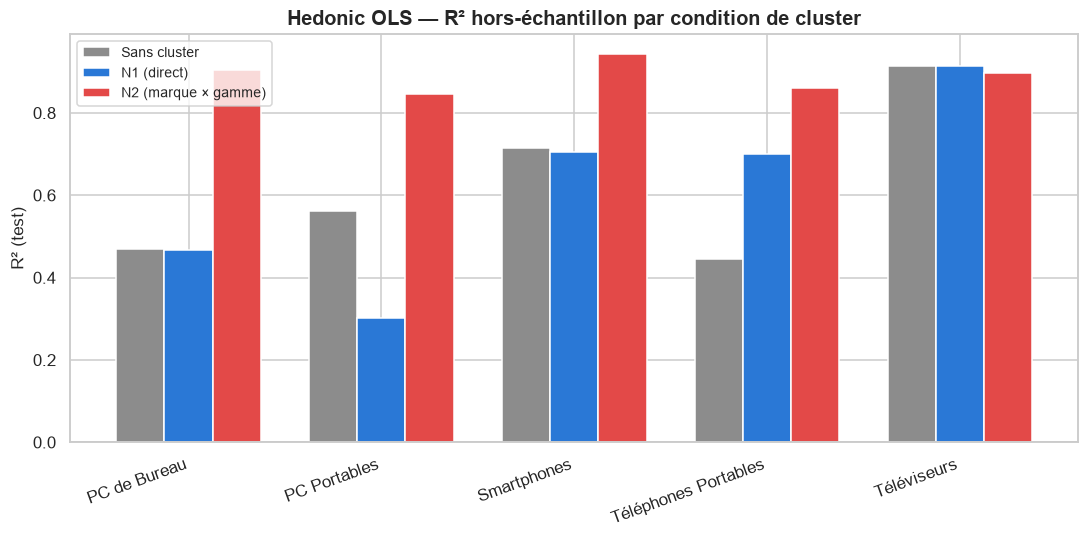

In [6]:
def plot_r2_by_condition(results, model_key, title):
    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(CATEGORY_ORDER))
    width = 0.25
    for i, cond in enumerate(CLUSTER_CONDITIONS):
        values = [results["categories"][cat]["conditions"][cond][model_key]["r2_test"] for cat in CATEGORY_ORDER]
        ax.bar(x + (i - 1) * width, values, width, label=CONDITION_LABELS[cond], color=COND_COLORS[cond])
    ax.set_xticks(x)
    ax.set_xticklabels([CATEGORY_LABELS[c] for c in CATEGORY_ORDER], rotation=20, ha="right")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set(title=title, ylabel="R² (test)")
    ax.legend(fontsize=9)
    plt.tight_layout(); plt.show()

plot_r2_by_condition(results, "hedonic_ols", "Hedonic OLS — R² hors-échantillon par condition de cluster")


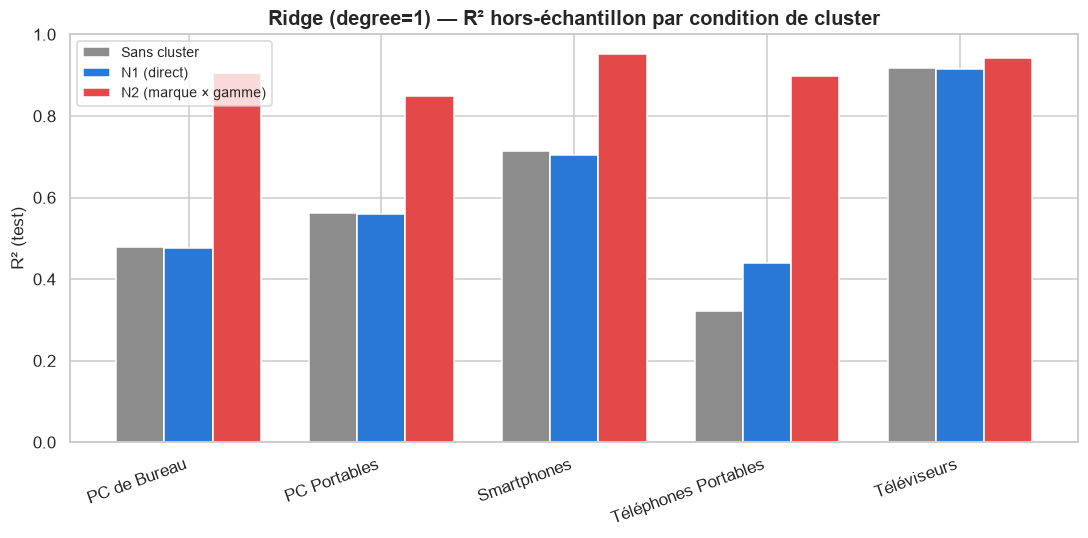

In [7]:
plot_r2_by_condition(results, "ridge", "Ridge (degree=1) — R² hors-échantillon par condition de cluster")


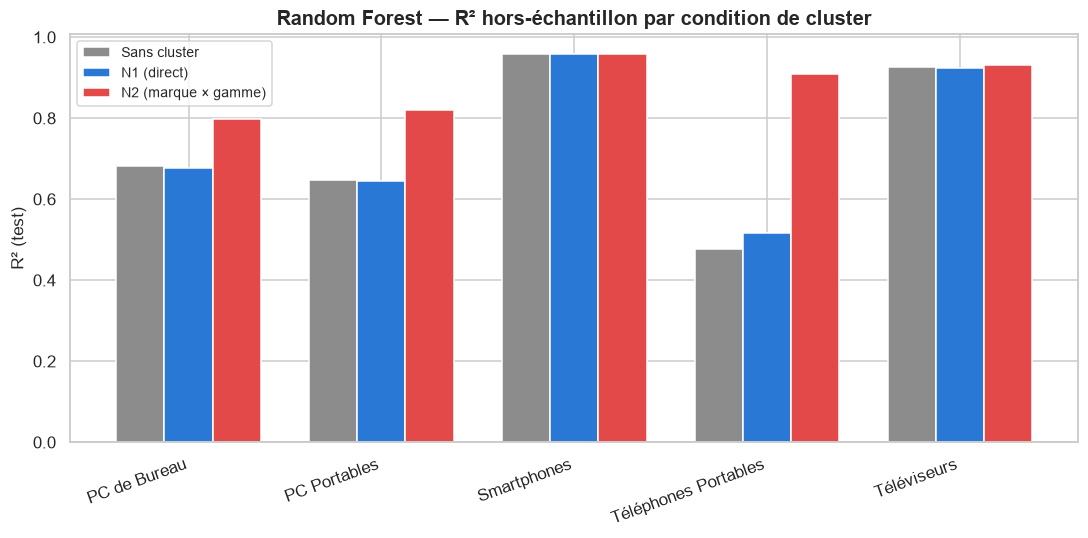

In [8]:
plot_r2_by_condition(results, "random_forest", "Random Forest — R² hors-échantillon par condition de cluster")


**PC de Bureau** (n_train=174, n_test=43) — meilleure combinaison : **Hedonic OLS** avec le cluster **N2 (marque × gamme)** (R² test = 0.905). Le cluster **N2** (marque × gamme) apporte le gain le plus net par rapport à l'absence de cluster (R² max 0.683 → 0.905) : connaître le positionnement marque/gamme d'un produit aide sensiblement à prédire son prix, au-delà des seules caractéristiques techniques.

**PC Portables** (n_train=422, n_test=106) — meilleure combinaison : **Ridge** avec le cluster **N2 (marque × gamme)** (R² test = 0.849). Le cluster **N2** (marque × gamme) apporte le gain le plus net par rapport à l'absence de cluster (R² max 0.647 → 0.849) : connaître le positionnement marque/gamme d'un produit aide sensiblement à prédire son prix, au-delà des seules caractéristiques techniques. Signal de fragilité notable : ajouter le cluster N1 fait **chuter** l'OLS non régularisé (R²=0.562 → 0.301) alors que Ridge reste stable (R²=0.560) -- exactement le cas d'usage pour lequel la pénalisation L2 existe : stabiliser un modèle linéaire quand des indicatrices ajoutent de la colinéarité/du sur-ajustement.

**Smartphones** (n_train=203, n_test=51) — meilleure combinaison : **Random Forest** avec le cluster **sans cluster** (R² test = 0.959). Ajouter l'information de cluster (N1 ou N2) n'améliore que marginalement la prédiction ici : les caractéristiques techniques seules portent déjà l'essentiel du pouvoir prédictif.

**Téléphones Portables** (n_train=55, n_test=14) — meilleure combinaison : **Random Forest** avec le cluster **N2 (marque × gamme)** (R² test = 0.908). Le cluster **N2** (marque × gamme) apporte le gain le plus net par rapport à l'absence de cluster (R² max 0.476 → 0.908) : connaître le positionnement marque/gamme d'un produit aide sensiblement à prédire son prix, au-delà des seules caractéristiques techniques.

**Téléviseurs** (n_train=90, n_test=22) — meilleure combinaison : **Ridge** avec le cluster **N2 (marque × gamme)** (R² test = 0.942). Ajouter l'information de cluster (N1 ou N2) n'améliore que marginalement la prédiction ici : les caractéristiques techniques seules portent déjà l'essentiel du pouvoir prédictif.


## 6. Importances de variables (Random Forest)

Pour chaque catégorie, top-5 caractéristiques par importance (réduction moyenne d'impurité), sous la condition
de cluster où Random Forest obtient son meilleur R² test.


In [9]:
for cat in CATEGORY_ORDER:
    conds = results["categories"][cat]["conditions"]
    best_cond = max(CLUSTER_CONDITIONS, key=lambda c: conds[c]["random_forest"]["r2_test"])
    top_feats = pd.DataFrame(conds[best_cond]["random_forest"]["top_features"])
    print(f"--- {CATEGORY_LABELS[cat]} (condition : {CONDITION_LABELS[best_cond]}) ---")
    print(top_feats.to_string(index=False))
    print()


--- PC de Bureau (condition : N2 (marque × gamme)) ---
                         feature  importance
                     stockage_go       0.587
group_n2_MYTEK | Économique | c0       0.073
                          ram_go       0.059
          group_n2_MSI | Premium       0.036
          os_platform_Windows 11       0.035

--- PC Portables (condition : N2 (marque × gamme)) ---
                        feature  importance
                    stockage_go       0.440
                         ram_go       0.116
                   taille_ecran       0.086
                  cpu_serie_3.0       0.063
group_n2_ASUS | Économique | c1       0.036

--- Smartphones (condition : Sans cluster) ---
     feature  importance
      ram_go       0.404
      has_5g       0.213
taille_ecran       0.187
 stockage_go       0.112
      has_4g       0.037

--- Téléphones Portables (condition : N2 (marque × gamme)) ---
                      feature  importance
                 taille_ecran       0.611
         

## 7. Étude de sensibilité aux valeurs extrêmes

Au-delà du cas ponctuel du §1, détection **systématique** des produits statistiquement atypiques : règle de
Tukey (bornes Q1 - 1,5×IQR / Q3 + 1,5×IQR), calculée sur le train de chaque catégorie, appliquée à
train **et** test. Un produit est « extrême » dès qu'**une seule** caractéristique continue sort de ses bornes.

**Piège rencontré et corrigé : IQR dégénéré.** Certaines tailles (stockage en particulier) sont si
standardisées dans ce catalogue que le 25ᵉ et le 75ᵉ centile tombent exactement sur la même valeur (ex. 512 Go)
— un IQR de 0, qui rendrait la règle de Tukey absurde (tout écart, même minime, serait signalé comme extrême :
observé empiriquement, 101/422 produits PC Portables flagués à cause du seul stockage avant correction). La
variable est alors ignorée pour la détection plutôt que de produire un flag non significatif — visible dans les
bornes affichées ci-dessous (`-inf`/`inf` pour les variables concernées).

Chaque catégorie est ensuite ré-estimée (3 modèles × 3 conditions) **sans** ces produits, pour comparer la
prédiction hors-échantillon avec/sans.


In [10]:
for cat in CATEGORY_ORDER:
    train_cat = attach_cluster_labels(train_all[train_all["categorie"] == cat].reset_index(drop=True), cat)
    test_cat = attach_cluster_labels(test_all[test_all["categorie"] == cat].reset_index(drop=True), cat)
    continuous_features, categorical_base = classify_features(pd.concat([train_cat, test_cat], ignore_index=True))

    bounds = detect_outliers_iqr(train_cat, continuous_features)
    train_outlier_mask = flag_outliers(train_cat, bounds)
    test_outlier_mask = flag_outliers(test_cat, bounds)

    train_clean = train_cat.loc[~train_outlier_mask].reset_index(drop=True)
    test_clean = test_cat.loc[~test_outlier_mask].reset_index(drop=True)
    combined_clean = pd.concat([train_clean.assign(_split="train"), test_clean.assign(_split="test")], ignore_index=True)

    cat_outlier_entry = {
        "bounds": {f: [float(lo), float(hi)] for f, (lo, hi) in bounds.items()},
        "n_outliers_train": int(train_outlier_mask.sum()), "n_outliers_test": int(test_outlier_mask.sum()),
        "conditions_sans_extremes": {},
    }
    if len(train_clean) >= 20 and len(test_clean) >= 5:
        for condition in CLUSTER_CONDITIONS:
            X_train_c, y_train_c, X_test_c, y_test_c = build_condition_matrices(combined_clean, continuous_features, categorical_base, condition)
            cat_outlier_entry["conditions_sans_extremes"][condition] = fit_and_evaluate(X_train_c, y_train_c, X_test_c, y_test_c, continuous_features)
    else:
        cat_outlier_entry["conditions_sans_extremes"] = None

    outlier_study["categories"][cat] = cat_outlier_entry
    print(f"{cat:<22} {train_outlier_mask.sum()} outlier(s) train, {test_outlier_mask.sum()} outlier(s) test "
          f"(bornes : {cat_outlier_entry['bounds']})")


pc_bureau              1 outlier(s) train, 1 outlier(s) test (bornes : {'ram_go': [-8.0, 56.0], 'stockage_go': [-286.0, 1810.0]})


pc_portables           43 outlier(s) train, 9 outlier(s) test (bornes : {'ram_go': [-16.0, 48.0], 'stockage_go': [-inf, inf], 'taille_ecran': [15.0, 16.6]})


smartphones            33 outlier(s) train, 9 outlier(s) test (bornes : {'ram_go': [-3.0, 21.0], 'stockage_go': [-64.0, 448.0], 'taille_ecran': [6.504999999999999, 6.945]})


telephones_portables   14 outlier(s) train, 5 outlier(s) test (bornes : {'ram_go': [-21.527343749999996, 35.96015625], 'stockage_go': [-inf, inf], 'taille_ecran': [1.425, 2.3449999999999998]})


televiseurs            3 outlier(s) train, 0 outlier(s) test (bornes : {'taille_ecran': [10.0, 98.0], 'taux_rafraichissement': [-6.75, 171.25]})


**PC de Bureau** — 1 produit(s) extrême(s) détecté(s) dans le train, 1 dans le test (règle de Tukey, 1,5×IQR). Bornes retenues : ram_go ∈ [-8.0, 56.0]; stockage_go ∈ [-286.0, 1810.0].

**PC Portables** — 43 produit(s) extrême(s) détecté(s) dans le train, 9 dans le test (règle de Tukey, 1,5×IQR). Variable(s) ignorée(s) pour la détection : **stockage_go** -- IQR dégénéré (Q1=Q3), une taille standardisée si fréquente dans ce catalogue que tout écart serait signalé à tort comme « extrême ». Bornes retenues : ram_go ∈ [-16.0, 48.0]; taille_ecran ∈ [15.0, 16.6].

**Smartphones** — 33 produit(s) extrême(s) détecté(s) dans le train, 9 dans le test (règle de Tukey, 1,5×IQR). Bornes retenues : ram_go ∈ [-3.0, 21.0]; stockage_go ∈ [-64.0, 448.0]; taille_ecran ∈ [6.5, 6.9].

**Téléphones Portables** — 14 produit(s) extrême(s) détecté(s) dans le train, 5 dans le test (règle de Tukey, 1,5×IQR). Variable(s) ignorée(s) pour la détection : **stockage_go** -- IQR dégénéré (Q1=Q3), une taille standardisée si fréquente dans ce catalogue que tout écart serait signalé à tort comme « extrême ». Bornes retenues : ram_go ∈ [-21.5, 36.0]; taille_ecran ∈ [1.4, 2.3].

**Téléviseurs** — 3 produit(s) extrême(s) détecté(s) dans le train, 0 dans le test (règle de Tukey, 1,5×IQR). Bornes retenues : taille_ecran ∈ [10.0, 98.0]; taux_rafraichissement ∈ [-6.8, 171.2].


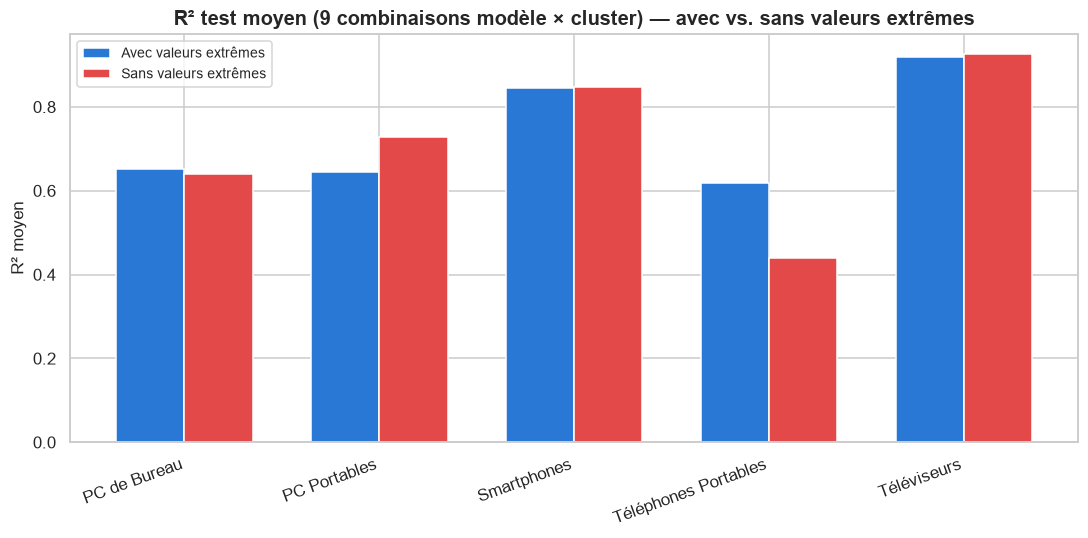

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(CATEGORY_ORDER))
width = 0.35
r2_avec = [np.mean([results["categories"][cat]["conditions"][c][m]["r2_test"]
                     for c in CLUSTER_CONDITIONS for m in MODEL_LABELS]) for cat in CATEGORY_ORDER]
r2_sans = []
for cat in CATEGORY_ORDER:
    cs = outlier_study["categories"][cat]["conditions_sans_extremes"]
    if cs is None:
        r2_sans.append(np.nan)
    else:
        r2_sans.append(np.mean([cs[c][m]["r2_test"] for c in CLUSTER_CONDITIONS for m in MODEL_LABELS]))

ax.bar(x - width / 2, r2_avec, width, label="Avec valeurs extrêmes", color="#2a78d6")
ax.bar(x + width / 2, r2_sans, width, label="Sans valeurs extrêmes", color="#e34948")
ax.set_xticks(x)
ax.set_xticklabels([CATEGORY_LABELS[c] for c in CATEGORY_ORDER], rotation=20, ha="right")
ax.set(title="R² test moyen (9 combinaisons modèle × cluster) — avec vs. sans valeurs extrêmes", ylabel="R² moyen")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


**PC de Bureau** (n_train 174→173, -1%) — un effet globalement neutre (ΔR² moyen = -0.012).

**PC Portables** (n_train 422→379, -10%) — **exclure améliore la prédiction en moyenne** (ΔR² moyen = +0.086 sur les 9 combinaisons modèle × cluster) -- les valeurs extrêmes détectées faussaient bien l'estimation.

**Smartphones** (n_train 203→170, -16%) — un effet globalement neutre (ΔR² moyen = +0.001).

**Téléphones Portables** (n_train 55→41, -25%) — **exclure dégrade la prédiction en moyenne** (ΔR² moyen = -0.179) -- avec 25% du train retiré, la perte de puissance statistique coûte plus cher que le bénéfice d'un échantillon plus propre.

**Téléviseurs** (n_train 90→87, -3%) — un effet globalement neutre (ΔR² moyen = +0.007).


## 8. Synthèse finale


**Synthèse.** Random Forest domine ou égale les deux modèles linéaires dans la quasi-totalité des configurations testées -- attendu, les prix technologiques suivent rarement une forme log-linéaire stricte (effets de seuil, interactions RAM×stockage×marque non explicitement modélisées côté OLS/Ridge). Mais l'écart se resserre nettement dès qu'un cluster **N2** est ajouté : une fois la marque et la gamme de prix connues, un simple OLS ou Ridge rattrape une bonne partie de l'avance de RF -- le cluster **N2 améliore sensiblement la prédiction hors-échantillon dans 3/5 catégories**, cohérent avec le pouvoir discriminant de prix déjà observé dans `Comparaison_Approches_Clustering.ipynb` (axe 4). Ce n'est pas une coïncidence : un clustering qui sépare bien les prix (silhouette, Kruskal-Wallis) sert aussi de bon prédicteur, exactement ce qu'on attend d'une segmentation économiquement sensée. Sur la sensibilité aux valeurs extrêmes : exclure les produits détectés comme atypiques (règle de Tukey) aide dans 1/5 catégories, nuit dans 1/5 (le plus souvent les petites catégories, où chaque ligne retirée coûte cher en puissance statistique) et reste neutre ailleurs -- **il n'existe pas de règle unique** : la décision d'exclure doit se prendre catégorie par catégorie, en pesant taille d'échantillon contre gain de robustesse, jamais par une règle automatique appliquée aveuglément à tout le catalogue.
